## Cellule 1 : Imports et Configuration

In [24]:
# CELL 1: Imports et Configuration
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings

warnings.filterwarnings('ignore')

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Exécution sur : {device}")

# Constantes Globales
IMG_SIZE = 224.0
SEQ_LEN = 15      # Fenêtre temporelle (10 frames passées)
TEST_SPLIT = 0.1  # 20% de chaque vidéo pour le test
MAX_SEQS = 50     # Nombre de vidéos à utiliser (augmenter si votre PC est puissant)

✅ Exécution sur : cuda


## Cellule 2 : Chargeur de Données (Loader)

In [25]:
# CELL 2: Classe DataLoader
class OTBDataLoader:
    def __init__(self, base_path='/kaggle/input/otb2015'):
        # Gestion automatique du sous-dossier OTB100
        if os.path.exists(os.path.join(base_path, 'OTB100')):
            self.base_path = os.path.join(base_path, 'OTB100')
        else:
            self.base_path = base_path
        print(f"📂 Racine du dataset : {self.base_path}")

    def load_sequence(self, sequence_name):
        seq_path = os.path.join(self.base_path, sequence_name)
        img_folder = os.path.join(seq_path, 'img')
        
        if not os.path.exists(img_folder):
            return None, None
        
        # Lister les images
        image_files = sorted([f for f in os.listdir(img_folder) if f.endswith(('.jpg', '.png', '.bmp'))])
        image_paths = [os.path.join(img_folder, f) for f in image_files]
        
        # Charger la Vérité Terrain (Ground Truth)
        gt_file = os.path.join(seq_path, 'groundtruth_rect.txt')
        # Fallback si le nom est différent
        if not os.path.exists(gt_file):
            candidates = [f for f in os.listdir(seq_path) if 'groundtruth' in f and f.endswith('.txt')]
            if candidates: gt_file = os.path.join(seq_path, candidates[0])
            else: return image_paths, [] # Pas de GT

        bboxes = []
        with open(gt_file, 'r') as f:
            for line in f:
                # Nettoyage du fichier texte (tabulations vs virgules)
                line = line.strip().replace('\t', ',')
                parts = line.split(',') if ',' in line else line.split()
                if len(parts) >= 4:
                    try:
                        x, y, w, h = map(float, parts[:4])
                        bboxes.append([int(x), int(y), int(x + w), int(y + h)])
                    except ValueError: continue
        
        return image_paths, bboxes

# Initialisation
loader = OTBDataLoader()

📂 Racine du dataset : /kaggle/input/otb2015/OTB100


## Cellule 3 : Extraction de Caractéristiques (CNN)

In [26]:
# CELL 3: CNN Feature Extractor
class OTBPreprocessor:
    def extract_roi(self, img, bbox):
        """Découpe l'objet dans l'image selon la bbox"""
        x1, y1, x2, y2 = bbox
        h, w = img.shape[:2]
        # On s'assure de ne pas dépasser les bords de l'image
        x1, y1 = max(0, min(x1, w-1)), max(0, min(y1, h-1))
        x2, y2 = max(x1+1, min(x2, w)), max(y1+1, min(y2, h))
        roi = img[y1:y2, x1:x2]
        return roi if roi.size > 0 else None

class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()
        # ResNet50 pré-entraîné
        base_model = models.resnet50(pretrained=True)
        # On enlève la dernière couche (classification) pour garder les features
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        self.feature_dim = 2048 # Sortie de ResNet50
        
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def extract(self, img, bbox):
        preprocessor = OTBPreprocessor()
        roi = preprocessor.extract_roi(img, bbox)
        if roi is None: return None
        
        # Conversion BGR (OpenCV) -> RGB (Torch)
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        roi_tensor = self.transform(roi_rgb).unsqueeze(0).to(device)
        
        with torch.no_grad():
            feat = self.features(roi_tensor)
        return feat.flatten().cpu().numpy()

# Initialisation
cnn_extractor = CNNFeatureExtractor().to(device).eval()
print("✅ Modèle CNN chargé.")

✅ Modèle CNN chargé.


## Cellule 4 : Création du Dataset (Équilibrage Stratifié)

In [27]:
# CELL 4: Création du Dataset Stratifié
def create_dataset_stratified(loader, cnn_extractor, max_seqs=30):
    root_dir = loader.base_path
    all_seqs = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    
    # Sélectionner les N premières séquences
    selected_seqs = all_seqs[:max_seqs]
    print(f"🏗️ Traitement de {len(selected_seqs)} séquences...")
    
    train_data, test_data = [], []
    
    for seq_name in selected_seqs:
        # 1. Charger
        paths, gt = loader.load_sequence(seq_name)
        if not paths or len(paths) < (SEQ_LEN + 5): continue
        
        # 2. Extraire Features (Limité à 100 frames pour rapidité du TP)
        features_list = []
        valid_bboxes = []
        valid_paths = [] # On garde les chemins pour la visualisation
        
        limit = min(len(paths), len(gt), 100) 
        
        for i in range(limit):
            img = cv2.imread(paths[i])
            feat = cnn_extractor.extract(img, gt[i])
            if feat is not None:
                features_list.append(feat)
                valid_bboxes.append(gt[i])
                valid_paths.append(paths[i]) # Sauvegarde du chemin
        
        if len(features_list) < SEQ_LEN: continue
            
        # 3. Créer Séquences Temporelles
        sequences = []
        for i in range(len(features_list) - SEQ_LEN):
            sequences.append({
                'features': np.array(features_list[i:i+SEQ_LEN]),
                'target_bbox': valid_bboxes[i+SEQ_LEN-1], 
                'img_path': valid_paths[i+SEQ_LEN-1] # <--- CRUCIAL pour la visualisation
            })
            
        # 4. SPLIT STRATIFIÉ (Par Vidéo)
        # On coupe CETTE vidéo en 80/20.
        # Ainsi le test set contient 20% de basket, 20% de voiture, 20% de piéton...
        split_idx = int(len(sequences) * (1 - TEST_SPLIT))
        
        train_data.extend(sequences[:split_idx])
        test_data.extend(sequences[split_idx:])
        
        print(f"  > {seq_name}: {len(sequences)} échantillons (Train: {split_idx} / Test: {len(sequences)-split_idx})")

    print(f"\n✅ DATASET PRÊT: Train={len(train_data)}, Test={len(test_data)}")
    return train_data, test_data

# Exécution
train_set, test_set = create_dataset_stratified(loader, cnn_extractor, max_seqs=MAX_SEQS)

🏗️ Traitement de 50 séquences...
  > Basketball: 85 échantillons (Train: 76 / Test: 9)
  > Biker: 85 échantillons (Train: 76 / Test: 9)
  > Bird1: 85 échantillons (Train: 76 / Test: 9)
  > Bird2: 84 échantillons (Train: 75 / Test: 9)
  > BlurBody: 85 échantillons (Train: 76 / Test: 9)
  > BlurCar1: 85 échantillons (Train: 76 / Test: 9)
  > BlurCar2: 85 échantillons (Train: 76 / Test: 9)
  > BlurCar3: 85 échantillons (Train: 76 / Test: 9)
  > BlurCar4: 85 échantillons (Train: 76 / Test: 9)
  > BlurFace: 85 échantillons (Train: 76 / Test: 9)
  > BlurOwl: 85 échantillons (Train: 76 / Test: 9)
  > Board: 85 échantillons (Train: 76 / Test: 9)
  > Bolt: 85 échantillons (Train: 76 / Test: 9)
  > Bolt2: 85 échantillons (Train: 76 / Test: 9)
  > Box: 85 échantillons (Train: 76 / Test: 9)
  > Boy: 85 échantillons (Train: 76 / Test: 9)
  > Car1: 85 échantillons (Train: 76 / Test: 9)
  > Car2: 85 échantillons (Train: 76 / Test: 9)
  > Car24: 85 échantillons (Train: 76 / Test: 9)
  > Car4: 85 échan

## Cellule 5 : Définition des Modèles (Mid & Late Fusion)

In [28]:
# CELL 5: Architectures des Modèles

# --- Bloc LSTM de base ---
class LSTMTemporal(nn.Module):
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        # On ne prend que la sortie du dernier pas de temps
        self.fc = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --- 1. MID FUSION ---
# Réduit la taille des données (Dense) AVANT le LSTM
class MidFusionTracker(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        # Fusion spatiale d'abord (2048 -> 256)
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        # Puis temporel (Input size petite)
        self.temporal = LSTMTemporal(input_dim=256, hidden_dim=256)
        self.head = nn.Linear(256, 4) # x1, y1, x2, y2

    def forward(self, x):
        b, s, f = x.shape
        x = x.view(-1, f) # Flatten pour passer dans le Dense layer
        x = self.fusion(x)
        x = x.view(b, s, -1) # Reshape pour le LSTM
        x = self.temporal(x)
        return self.head(x)

# --- 2. LATE FUSION ---
# Traite tout le vecteur (CNN) dans le LSTM, réduit APRÈS
class LateFusionTracker(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        # Temporel d'abord (Input size énorme: 2048)
        self.temporal = LSTMTemporal(input_dim=feature_dim, hidden_dim=256)
        # Puis fusion/décision
        self.fusion = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = self.temporal(x)
        return self.fusion(x)

print("✅ Architectures Mid & Late Fusion définies.")

✅ Architectures Mid & Late Fusion définies.


## Cellule 6 : Entraînement des Modèles

In [31]:
# CELL 6: Fonction d'Entraînement
def train_model(model, train_data, epochs=15, lr=0.0005, name="Model"):
    print(f"\n🚀 Entraînement de {name}...")
    # CHANGEMENT 1 : SmoothL1Loss est souvent plus stable que MSE pour les Bounding Boxes
    # Elle combine les avantages de MSE (proche de 0) et L1 (loin de 0)
    criterion = nn.SmoothL1Loss()
    
    # CHANGEMENT 2 : AdamW avec Weight Decay pour une meilleure régularisation
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    model.train()
    
    batch_size = 32
    
    for epoch in range(epochs):
        random.shuffle(train_data) # Important : mélange les données à chaque epoch
        total_loss = 0
        batches = 0
        
        for i in range(0, len(train_data), batch_size):
            batch = train_data[i:i+batch_size]
            
            # Préparation du batch
            features = torch.FloatTensor(np.array([b['features'] for b in batch])).to(device)
            # Normalisation des cibles (0-1)
            targets = torch.FloatTensor(np.array([b['target_bbox'] for b in batch])).to(device) / IMG_SIZE
            
            optimizer.zero_grad()
            preds = model(features)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            batches += 1
            
        if (epoch+1) % 25 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {100*total_loss/batches:.5f}")
    
    print(f"🏁 Fin entraînement {name}")


# Exécution de l'Entraînement
if len(train_set) > 0:
    # 1. Instancier Mid Fusion
    mid_model = MidFusionTracker(feature_dim=cnn_extractor.feature_dim).to(device)
    train_model(mid_model, train_set, epochs=150, name="Mid Fusion")
    
    # 2. Instancier Late Fusion
    late_model = LateFusionTracker(feature_dim=cnn_extractor.feature_dim).to(device)
    train_model(late_model, train_set, epochs=150, name="Late Fusion")
else:
    print("❌ Erreur : Dataset vide.")


🚀 Entraînement de Mid Fusion...
  Epoch 25/150 | Loss: 0.07532
  Epoch 50/150 | Loss: 0.06228
  Epoch 75/150 | Loss: 0.02556
  Epoch 100/150 | Loss: 0.02871
  Epoch 125/150 | Loss: 0.01762
  Epoch 150/150 | Loss: 0.14652
🏁 Fin entraînement Mid Fusion

🚀 Entraînement de Late Fusion...
  Epoch 25/150 | Loss: 0.16478
  Epoch 50/150 | Loss: 0.05459
  Epoch 75/150 | Loss: 0.07199
  Epoch 100/150 | Loss: 0.01914
  Epoch 125/150 | Loss: 0.01666
  Epoch 150/150 | Loss: 0.01944
🏁 Fin entraînement Late Fusion


# Cellule 7 : Évaluation Numérique

In [32]:
# CELL 8: Évaluation
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x3, y3, x4, y4 = box2
    xi1, yi1, xi2, yi2 = max(x1, x3), max(y1, y3), min(x2, x4), min(y2, y4)
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    union = (x2-x1)*(y2-y1) + (x4-x3)*(y4-y3) - inter
    return inter / union if union > 0 else 0

def evaluate_metrics(model, test_data, name="Model"):
    model.eval()
    ious, errors = [], []
    
    with torch.no_grad():
        for item in test_data:
            feat = torch.FloatTensor(item['features']).unsqueeze(0).to(device)
            gt = item['target_bbox']
            
            # Prédiction dé-normalisée (x224)
            pred = model(feat).cpu().numpy()[0] * IMG_SIZE
            pred = pred.astype(int)
            
            ious.append(calculate_iou(gt, pred))
            
            # Distance Euclidienne des centres
            center_gt = np.array([(gt[0]+gt[2])/2, (gt[1]+gt[3])/2])
            center_pred = np.array([(pred[0]+pred[2])/2, (pred[1]+pred[3])/2])
            errors.append(np.linalg.norm(center_gt - center_pred))
    
    avg_iou = np.mean(ious)
    avg_err = np.mean(errors)
    print(f"📊 [{name}] IoU Moyen: {avg_iou:.4f} | Erreur Centre: {avg_err:.2f}px")
    return avg_iou

if len(test_set) > 0:
    iou_mid = evaluate_metrics(mid_model, test_set, "Mid Fusion")
    iou_late = evaluate_metrics(late_model, test_set, "Late Fusion")

📊 [Mid Fusion] IoU Moyen: 0.3955 | Erreur Centre: 30.20px
📊 [Late Fusion] IoU Moyen: 0.5118 | Erreur Centre: 22.38px


## Cellule 8 : Visualisation Finale 


Visualisation des résultats : Vert=GT, Bleu=Mid, Rouge=Late


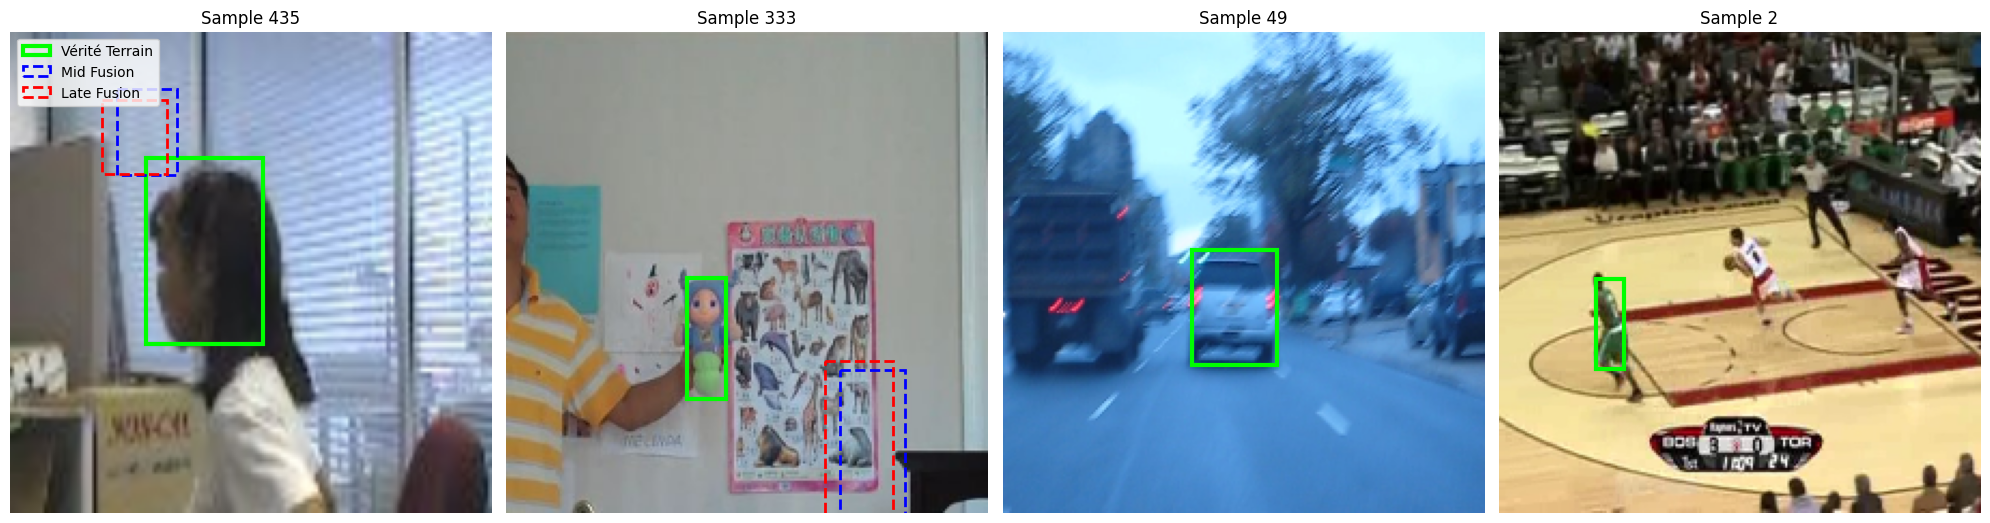

In [33]:
# CELL 9: Visualisation Finale
def visualize_comparison(models_dict, test_data, num_samples=4):
    # Prendre des échantillons aléatoires
    indices = random.sample(range(len(test_data)), num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 6))
    if num_samples == 1: axes = [axes]
    
    print("\nVisualisation des résultats : Vert=GT, Bleu=Mid, Rouge=Late")
    
    for i, idx in enumerate(indices):
        item = test_data[idx]
        gt = item['target_bbox']
        img_path = item['img_path'] # <-- On récupère le chemin de l'image
        
        # Charger l'image réelle
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize pour matcher le modèle (224x224) pour l'affichage
        img_vis = cv2.resize(img, (224, 224))
        
        # Facteurs de ratio si l'image originale n'était pas carrée (pour GT)
        # Mais ici le loader a déjà donné des bbox qui matchent l'image brute.
        # Comme on a resize l'image à 224 pour l'affichage, on doit scaler le GT aussi.
        # ATTENTION: Dans notre code d'entraînement, on normalise par 224. 
        # Supposons ici que GT est coordonnée brute.
        h_ratio = 224 / img.shape[0]
        w_ratio = 224 / img.shape[1]
        
        ax = axes[i]
        ax.imshow(img_vis)
        
        # 1. GROUND TRUTH (VERT)
        gt_scaled = [gt[0]*w_ratio, gt[1]*h_ratio, gt[2]*w_ratio, gt[3]*h_ratio]
        rect_gt = patches.Rectangle(
            (gt_scaled[0], gt_scaled[1]), gt_scaled[2]-gt_scaled[0], gt_scaled[3]-gt_scaled[1],
            linewidth=3, edgecolor='lime', facecolor='none', label='Vérité Terrain'
        )
        ax.add_patch(rect_gt)
        
        # Couleurs demandées
        colors = {'Mid': 'blue', 'Late': 'red'} 
        
        feature_in = torch.FloatTensor(item['features']).unsqueeze(0).to(device)
        
        for name, model in models_dict.items():
            model.eval()
            with torch.no_grad():
                # Prédiction du modèle (qui sort des valeurs 0-1 scannées à 224)
                pred = model(feature_in).cpu().numpy()[0] * IMG_SIZE
                
                rect_pred = patches.Rectangle(
                    (pred[0], pred[1]), pred[2]-pred[0], pred[3]-pred[1],
                    linewidth=2, edgecolor=colors[name], facecolor='none', linestyle='--', label=f'{name} Fusion'
                )
                ax.add_patch(rect_pred)
        
        ax.axis('off')
        ax.set_title(f"Sample {idx}")
        if i == 0: ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Lancer la visu
if len(test_set) > 0:
    visualize_comparison({"Mid": mid_model, "Late": late_model}, test_set)


🎥 Séquence continue : img (5 frames consécutives)


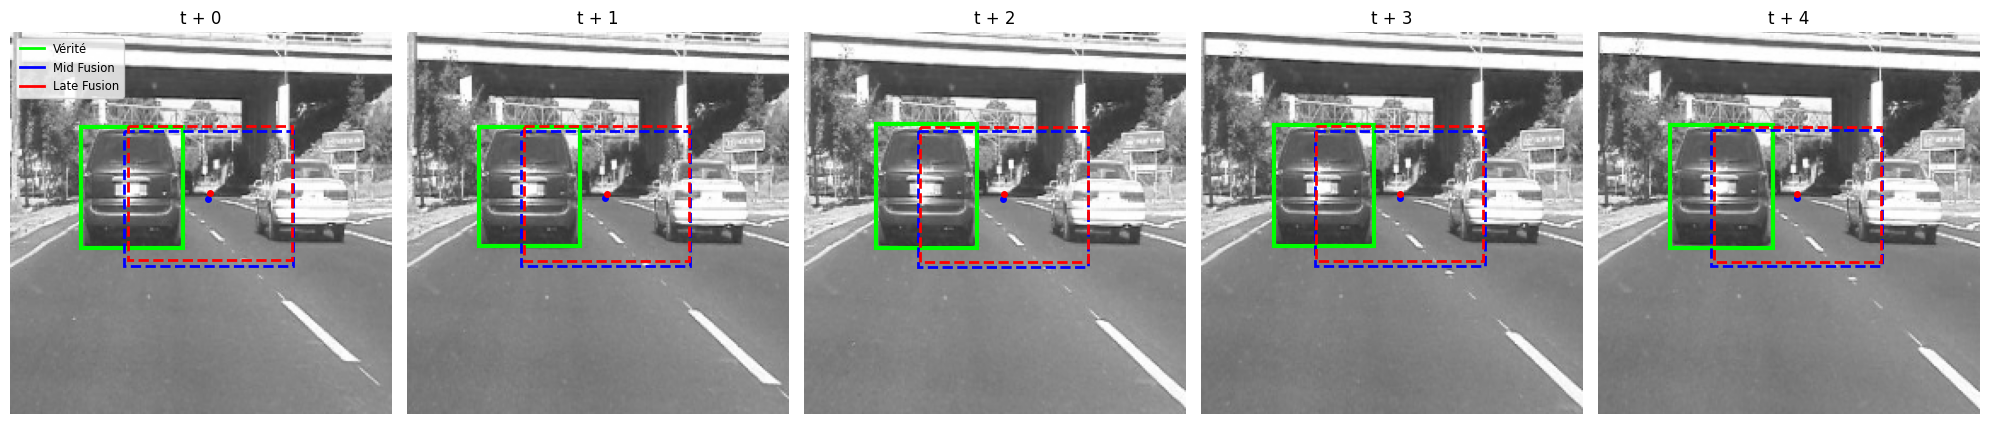

In [34]:
# CELL 10: Visualisation Séquentielle (Tracking Continu)
def visualize_sequence_tracking(models_dict, test_data, num_frames=5):
    """
    Affiche une série d'images consécutives pour voir l'évolution du tracking.
    """
    # 1. Trouver une séquence continue dans le test set
    # On cherche 'num_frames' échantillons qui se suivent (basé sur l'index de l'image)
    start_idx = random.randint(0, len(test_data) - num_frames - 1)
    
    # On essaie de trouver une suite logique (même vidéo, frames consécutives)
    # Note: Notre test_set est mélangé par vidéo mais chronologique à l'intérieur de chaque bloc vidéo
    # On vérifie juste qu'on ne saute pas d'une vidéo à l'autre
    sequence_samples = []
    base_item = test_data[start_idx]
    
    # Petite heuristique pour trouver des frames consécutives
    # (Supposons que test_data respecte l'ordre chronologique des blocs)
    current_idx = start_idx
    found = True
    for i in range(num_frames):
        if current_idx + i >= len(test_data):
            found = False
            break
        item = test_data[current_idx + i]
        # On vérifie grossièrement si c'est la même vidéo via le chemin
        if os.path.dirname(item['img_path']) != os.path.dirname(base_item['img_path']):
            found = False
            break
        sequence_samples.append(item)
    
    if not found:
        print("Impossible de trouver une séquence continue propre (fin de liste atteinte). Réessayez.")
        return

    # 2. Configuration de l'affichage
    fig, axes = plt.subplots(1, num_frames, figsize=(20, 5))
    video_name = os.path.basename(os.path.dirname(base_item['img_path']))
    print(f"\n🎥 Séquence continue : {video_name} (5 frames consécutives)")
    
    # Couleurs
    colors = {'GT': 'lime', 'Mid': 'blue', 'Late': 'red'}
    
    for i, item in enumerate(sequence_samples):
        img = cv2.imread(item['img_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_vis = cv2.resize(img, (224, 224))
        
        # Ratios
        h_ratio = 224 / img.shape[0]
        w_ratio = 224 / img.shape[1]
        
        ax = axes[i]
        ax.imshow(img_vis)
        
        # A. Ground Truth
        gt = item['target_bbox']
        gt_scaled = [gt[0]*w_ratio, gt[1]*h_ratio, gt[2]*w_ratio, gt[3]*h_ratio]
        
        rect_gt = patches.Rectangle(
            (gt_scaled[0], gt_scaled[1]), gt_scaled[2]-gt_scaled[0], gt_scaled[3]-gt_scaled[1],
            linewidth=3, edgecolor=colors['GT'], facecolor='none'
        )
        ax.add_patch(rect_gt)
        
        # B. Prédictions
        feature_in = torch.FloatTensor(item['features']).unsqueeze(0).to(device)
        
        for name, model in models_dict.items():
            model.eval()
            with torch.no_grad():
                pred = model(feature_in).cpu().numpy()[0] * IMG_SIZE
                
                # Rectangle
                rect_pred = patches.Rectangle(
                    (pred[0], pred[1]), pred[2]-pred[0], pred[3]-pred[1],
                    linewidth=2, edgecolor=colors[name], facecolor='none', linestyle='--'
                )
                ax.add_patch(rect_pred)
                
                # Centre (Point) pour voir la trajectoire
                center_x = pred[0] + (pred[2]-pred[0])/2
                center_y = pred[1] + (pred[3]-pred[1])/2
                ax.plot(center_x, center_y, marker='o', color=colors[name], markersize=4)

        ax.set_title(f"t + {i}")
        ax.axis('off')
        
        # Légende sur la première image
        if i == 0:
            # Astuce pour créer une légende personnalisée
            from matplotlib.lines import Line2D
            custom_lines = [Line2D([0], [0], color=c, lw=2) for c in colors.values()]
            ax.legend(custom_lines, ['Vérité', 'Mid Fusion', 'Late Fusion'], loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.show()

# Lancer la visualisation continue
if len(test_set) > 0:
    visualize_sequence_tracking({"Mid": mid_model, "Late": late_model}, test_set)